# Análise Estatística Descritiva — Missões Espaciais (1957–2022)

Estatística Descritiva - tabelas de frequência, gráficos, análises univariadas e relatório técnico.

Este notebook percorre, de ponta a ponta, a análise exploratória de uma base **real** de missões espaciais:

1. Seleção e justificativa da base de dados
2. Tabelas de distribuição de frequências (variável discreta e contínua)
3. Gráficos estatísticos
4. Análises univariadas (medidas de tendência central, dispersão e separatrizes)
5. Relatório estatístico e interpretação dos resultados



## 1. Seleção e Justificativa da Base de Dados

**Base escolhida:** *Space Missions* — registro de todos os lançamentos orbitais e suborbitais da história, de **4 de outubro de 1957** (Sputnik‑1) a **agosto de 2022**.

**Origem (dado real, não simulado):** os dados são coletados do portal **Next Spaceflight** (nextspaceflight.com), referência pública de calendário de lançamentos, e disponibilizados em repositórios abertos como o **Kaggle** e o **Maven Analytics Data Playground**. Cada linha corresponde a uma missão efetivamente realizada, com organização responsável, local, data/hora, veículo lançador, custo e desfecho.

**Justificativa técnica da escolha:**

- **Relevância e aderência ao tema.** O setor espacial é estratégico e de alto valor econômico; a base permite analisar custo, confiabilidade e dinâmica de mercado — exatamente o tipo de problema de negócio em que a estatística descritiva agrega valor.
- **Qualidade e estrutura.** São **4.626 registros** e **9 variáveis** originais, com tipos bem definidos (numéricas e categóricas) e cobertura temporal de ~65 anos, o que confere robustez amostral e profundidade histórica.
- **Potencial analítico.** Combina variáveis **quantitativas** (ano, preço) e **qualitativas** (organização, país, status), viabilizando tabelas de frequência, gráficos, medidas-resumo e cortes temporais/geográficos.
- **Limitações reconhecidas (transparência).** A variável **Preço** está disponível para ~27% das missões (custos de muitos veículos não são públicos) e o campo **Time** traz um artefato de exportação (data‑base do Excel `1899‑12‑30`), do qual apenas a hora é válida. Essas limitações são declaradas e tratadas ao longo da análise.

In [15]:
# Dependências
!pip install pandas numpy matplotlib

# Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Liga as tabelas interativas do Colab
try:
    from google.colab import data_table
    data_table.enable_dataframe_formatter()
except ModuleNotFoundError:
    pass

print("Tudo pronto! pandas", pd.__version__, "| numpy", np.__version__)

Tudo pronto! pandas 2.2.2 | numpy 2.0.2


In [16]:
CAMINHO_CSV = "/content/space_missions1.csv"

df = pd.read_csv(CAMINHO_CSV, encoding="utf-8-sig")

print("Base carregada com sucesso!")
print("Número de linhas (missões):", df.shape[0])
print("Número de colunas:", df.shape[1])

df.head()

Base carregada com sucesso!
Número de linhas (missões): 4626
Número de colunas: 9


,Company,Location,Year,Time,Rocket,MissionStatus,RocketStatus,Price,Mission
0,AEB,"VLS Pad, Alcântara Launch Center, Maranhão, Br...",1997,NaN,VLS-1,0,Retired,NaN,SCD-2A
1,AEB,"VLS Pad, Alcântara Launch Center, Maranhão, Br...",1999,1899-12-30 19:40:00,VLS-1,0,Retired,NaN,SACI-2
2,AEB,"VLS Pad, Alcântara Launch Center, Maranhão, Br...",2003,NaN,VLS-1,0,Retired,NaN,"SATEC, UNOSAT"
3,AMBA,"LA-5B, RAAF Woomera Range Complex, Australia",1967,NaN,Redstone Sparta,1,Retired,NaN,WRESAT
4,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA",1958,1899-12-30 03:48:00,Juno I,1,Retired,NaN,Explorer 1


In [17]:
# Para cada coluna, vamos ver o tipo de dado e quantos valores estão faltando
qualidade = pd.DataFrame()
qualidade["Tipo"] = df.dtypes.astype(str)
qualidade["Valores ausentes"] = df.isnull().sum()
qualidade["Ausentes (%)"] = (df.isnull().sum() / len(df) * 100).round(1)
qualidade.index.name = "Variável"

qualidade

,Tipo,Valores ausentes,Ausentes (%)
Variável,,,
Company,object,0,0.0
Location,object,0,0.0
Year,int64,0,0.0
Time,object,125,2.7
Rocket,object,0,0.0
MissionStatus,int64,0,0.0
RocketStatus,object,0,0.0
Price,float64,3362,72.7
Mission,object,0,0.0


### Dicionário de variáveis

| Variável | Descrição | Natureza |
|---|---|---|
| `Company` | Organização responsável pelo lançamento | Qualitativa nominal |
| `Location` | Local de lançamento (base, país) | Qualitativa nominal |
| `Year` | Ano do lançamento | **Quantitativa discreta** |
| `Time` | Horário do lançamento (apenas a hora é válida) | Quantitativa (tempo) |
| `Rocket` | Nome do veículo lançador | Qualitativa nominal |
| `MissionStatus` | Desfecho: `1` = Sucesso, `0` = Falha | Qualitativa binária |
| `RocketStatus` | Situação do foguete: `Active` / `Retired` | Qualitativa nominal |
| `Price` | Custo do lançamento (US$ milhões) | **Quantitativa contínua** |
| `Mission` | Nome da missão/carga útil | Qualitativa nominal |

As duas variáveis quantitativas centrais da análise são **`Year`** (discreta) e **`Price`** (contínua).

In [18]:


# 1) País de lançamento:
def pegar_pais(local):
    partes = local.split(",")
    return partes[-1].strip()

df["Country"] = df["Location"].apply(pegar_pais)

# 2) Década do lançamento
df["Decade"] = (df["Year"] // 10) * 10
df["DecadeLbl"] = df["Decade"].astype(str) + "s"

# 3) Rótulo de texto para o resultado da missão
df["StatusLbl"] = df["MissionStatus"].map({1: "Sucesso", 0: "Falha"})

# Alguns números gerais sobre a base
print("Período coberto:", df["Year"].min(), "a", df["Year"].max())
print("Organizações diferentes:", df["Company"].nunique())
print("Foguetes diferentes:", df["Rocket"].nunique())
print("Países diferentes:", df["Country"].nunique())

taxa_sucesso_geral = df["MissionStatus"].mean() * 100
print("Taxa de sucesso geral:", round(taxa_sucesso_geral, 1), "%")

# Coluna de preços
preco = df["Price"].dropna()
print("Missões com preço informado:", len(preco), "de", len(df))

Período coberto: 1957 a 2022
Organizações diferentes: 62
Foguetes diferentes: 370
Países diferentes: 22
Taxa de sucesso geral: 89.9 %
Missões com preço informado: 1264 de 4626


## 2. Tabelas de Distribuição de Frequências

Uma tabela de distribuição de frequências serve para **resumir muitos dados em poucas linhas**, mostrando quantas vezes cada valor (ou faixa de valores) aparece. Nas duas tabelas a seguir, cada coluna significa:

- **Quantidade de lançamentos** — quantos lançamentos houve naquela linha (a contagem direta);
- **Porcentagem (%)** — quanto isso representa do total (por exemplo, 20% = um quinto de tudo);
- **Quantidade acumulada** — a soma da linha atual com todas as anteriores (vai somando de cima para baixo);
- **Porcentagem acumulada (%)** — a mesma soma, só que em porcentagem (a última linha sempre chega a 100%).

Vamos construir uma tabela para a variável **ano de lançamento** e outra para o **preço do lançamento**.

### 2.1 Primeira tabela — Ano de lançamento (agrupado por década)

O **ano** é uma variável **quantitativa discreta** (são números inteiros que dá para contar). Como existem **66 anos diferentes** (de 1957 a 2022), mostrar ano por ano deixaria a tabela enorme e difícil de ler. Por isso agrupamos os anos por **década** (anos 1950, 1960, 1970…), o que facilita enxergar a evolução ao longo do tempo.

In [19]:
#quantos lançamentos houve em cada década
contagem = df["DecadeLbl"].value_counts().sort_index()

#tabela de frequências
tabela_discreta = pd.DataFrame()
tabela_discreta["Quantidade de lançamentos"] = contagem
tabela_discreta["Porcentagem (%)"] = (contagem / contagem.sum() * 100).round(2)
tabela_discreta["Quantidade acumulada"] = contagem.cumsum()
tabela_discreta["Porcentagem acumulada (%)"] = (tabela_discreta["Quantidade acumulada"] / contagem.sum() * 100).round(2)
tabela_discreta.index.name = "Década"

tabela_discreta.loc["TOTAL"] = [contagem.sum(), 100.00, "-", "-"]

print("Tabela 2.1 - Quantidade de lançamentos por década")
tabela_discreta

Tabela 2.1 - Quantidade de lançamentos por década


,Quantidade de lançamentos,Porcentagem (%),Quantidade acumulada,Porcentagem acumulada (%)
Década,,,,
1950s,51,1.10,51,1.1
1960s,773,16.71,824,17.81
1970s,1012,21.88,1836,39.69
1980s,631,13.64,2467,53.33
1990s,641,13.86,3108,67.19
2000s,474,10.25,3582,77.43
2010s,675,14.59,4257,92.02
2020s,369,7.98,4626,100.0
TOTAL,4626,100.00,-,-


**O que esta tabela mostra.** Cada linha é uma década e mostra quantos foguetes foram lançados naquele período.

- A coluna **Quantidade de lançamentos** revela que os **anos 1970 foram o auge**, com **1.012 lançamentos** — a maior quantidade de toda a história. Foi o período da corrida espacial entre Estados Unidos e União Soviética.
- A coluna **Porcentagem (%)** mostra o peso de cada década no total: sozinhos, os anos 1970 representam cerca de **22%** de todos os lançamentos já feitos.
- A coluna **Porcentagem acumulada (%)** vai somando as décadas. Repare que, ao chegar ao fim dos anos 1980, ela já marca **53,33%** — ou seja, **mais da metade** de todos os lançamentos da história aconteceram até 1989.
- Depois há uma **queda** nos anos 2000 (apenas 474 lançamentos) e uma **retomada** a partir de 2010 (675), impulsionada por empresas privadas como a SpaceX.

Em resumo: a atividade espacial começou devagar, explodiu nas décadas da Guerra Fria, recuou e voltou a crescer nos últimos anos.

### 2.2 Segunda tabela — Preço do lançamento (em faixas de custo)

O **preço** é uma variável **quantitativa contínua** (pode assumir qualquer valor, como US$ 63,5 milhões). Para resumir esses valores, agrupamos os preços em **faixas** (de US$ 2 a 30 milhões, de 30 a 60, e assim por diante). Cada faixa funciona como uma "gaveta": colocamos cada lançamento na gaveta do seu preço e contamos quantos caíram em cada uma. A coluna **Ponto médio** é apenas o valor central de cada faixa (por exemplo, o meio da faixa de 30 a 60 é 45).

In [20]:
n = len(preco)
k = round(1 + 3.322 * np.log10(n))
print("Total de lançamentos com preço informado:", n)
print("A regra de Sturges sugere", k, "faixas; como os preços são muito desiguais,")
print("usamos faixas de custo de mercado (mais fáceis de interpretar).\n")
print("Tabela 2.2 - Quantidade de lançamentos por faixa de preço (US$ milhões)")

#faixas, o nome de faixa e o ponto médio de cada uma
limites = [2, 30, 60, 100, 200, 500, 5001]
nomes   = ["2 a 30", "30 a 60", "60 a 100", "100 a 200", "200 a 500", "500 a 5000"]
pontos  = [16.0, 45.0, 80.0, 150.0, 350.0, 2750.0]

faixa = pd.cut(preco, bins=limites, labels=nomes, right=False)
contagem = faixa.value_counts().sort_index()

#tabela de frequências
tabela_continua = pd.DataFrame(index=nomes)
tabela_continua.index.name = "Faixa de preço (US$ milhões)"
tabela_continua["Ponto médio"] = pontos
tabela_continua["Quantidade de lançamentos"] = contagem.values
tabela_continua["Porcentagem (%)"] = (tabela_continua["Quantidade de lançamentos"] / tabela_continua["Quantidade de lançamentos"].sum() * 100).round(2)
tabela_continua["Quantidade acumulada"] = tabela_continua["Quantidade de lançamentos"].cumsum()
tabela_continua["Porcentagem acumulada (%)"] = (tabela_continua["Quantidade acumulada"] / tabela_continua["Quantidade de lançamentos"].sum() * 100).round(2)

# Linha de totais
tabela_continua.loc["TOTAL"] = ["-", tabela_continua["Quantidade de lançamentos"].sum(), 100.00, "-", "-"]

tabela_continua

Total de lançamentos com preço informado: 1264
A regra de Sturges sugere 11 faixas; como os preços são muito desiguais,
usamos faixas de custo de mercado (mais fáceis de interpretar).

Tabela 2.2 - Quantidade de lançamentos por faixa de preço (US$ milhões)


,Ponto médio,Quantidade de lançamentos,Porcentagem (%),Quantidade acumulada,Porcentagem acumulada (%)
Faixa de preço (US$ milhões),,,,,
2 a 30,16.0,253,20.02,253,20.02
30 a 60,45.0,332,26.27,585,46.28
60 a 100,80.0,306,24.21,891,70.49
100 a 200,150.0,129,10.21,1020,80.7
200 a 500,350.0,229,18.12,1249,98.81
500 a 5000,2750.0,15,1.19,1264,100.0
TOTAL,-,1264,100.00,-,-


**O que esta tabela mostra.** Cada linha é uma faixa de preço e mostra quantos lançamentos custaram aquele valor.

- A maior parte dos lançamentos é **barata**: somando as três primeiras faixas (até US$ 100 milhões), a coluna **Porcentagem acumulada (%)** chega a cerca de **70%**. Ou seja, **7 em cada 10 lançamentos** custaram menos de US$ 100 milhões.
- A faixa mais comum é a de **US$ 30 a 60 milhões**, com 332 lançamentos (cerca de 26% do total).
- No outro extremo, lançamentos **muito caros são raros**: a faixa de US$ 500 a 5.000 milhões tem só **15 lançamentos** (pouco mais de 1%). Mesmo sendo poucos, são valores altíssimos — incluem o ônibus espacial e foguetes gigantes como o Saturn V e o Energiya/Buran (que chegou a US$ 5.000 milhões).

Em resumo: existem **muitos foguetes baratos e pouquíssimos foguetes extremamente caros**. Esses poucos valores altos "puxam" a média para cima, como veremos na próxima seção — por isso, para falar do preço "típico", a **mediana** é mais confiável que a média.

## 3. Gráficos Estatísticos

Quatro gráficos, com **variáveis diferentes**, todos com **título, rótulos de eixos, cores e legendas** quando aplicável.

### Gráfico 1 — Lançamentos por década (variável `Year`)

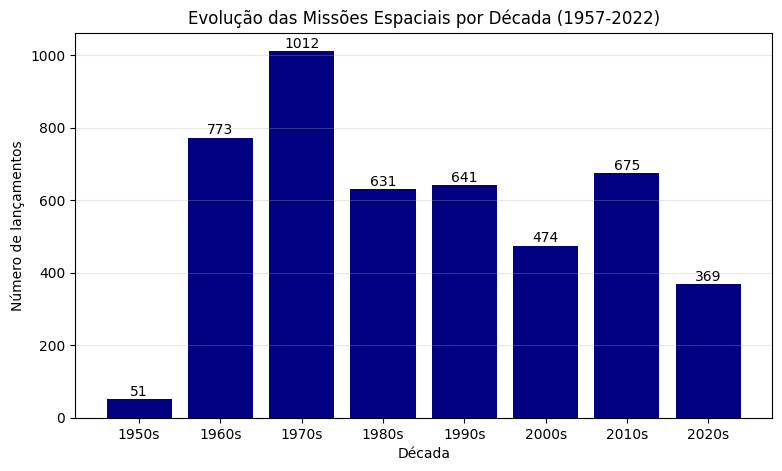

In [21]:
# Conta os lançamentos por década (em ordem)
contagem = df["DecadeLbl"].value_counts().sort_index()

plt.figure(figsize=(9, 5))
plt.bar(contagem.index, contagem.values, color="navy")

for i in range(len(contagem)):
    plt.text(i, contagem.values[i] + 10, str(contagem.values[i]), ha="center")

plt.title("Evolução das Missões Espaciais por Década (1957-2022)")
plt.xlabel("Década")
plt.ylabel("Número de lançamentos")
plt.grid(axis="y", alpha=0.3)
plt.show()

O perfil em "M" sintetiza a história do setor: pico nos anos 1970, recuo no pós‑Guerra Fria e forte recuperação recente.

### Gráfico 2 — Distribuição do preço (variável `Price`)

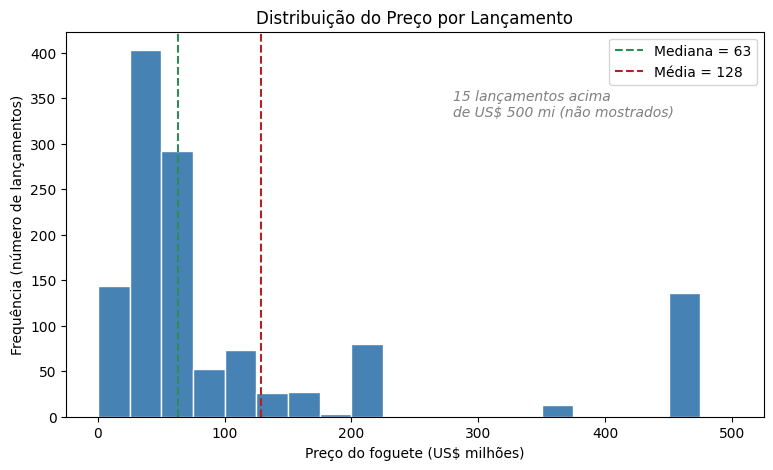

In [22]:
# Para o gráfico ficar legível,apenas os preços até 500 milhões.
# (existem poucos lançamentos acima disso e eles "esticam" demais o eixo)
precos_ate_500 = preco[preco <= 500]
quantos_acima = (preco > 500).sum()

media = preco.mean()
mediana = preco.median()

plt.figure(figsize=(9, 5))
plt.hist(precos_ate_500, bins=range(0, 525, 25), color="steelblue", edgecolor="white")

plt.axvline(mediana, color="seagreen", linestyle="--", label="Mediana = " + str(round(mediana)))
plt.axvline(media, color="firebrick", linestyle="--", label="Média = " + str(round(media)))

plt.title("Distribuição do Preço por Lançamento")
plt.xlabel("Preço do foguete (US$ milhões)")
plt.ylabel("Frequência (número de lançamentos)")
plt.text(280, 330, str(quantos_acima) + " lançamentos acima\nde US$ 500 mi (não mostrados)",
         color="gray", style="italic")
plt.legend()
plt.show()

A forma é claramente **assimétrica à direita**: a maioria se concentra em valores baixos e a média (vermelho) é puxada para a direita da mediana (verde) pela cauda de veículos caros.

### Gráfico 3 — Top 10 organizações (variável `Company`)

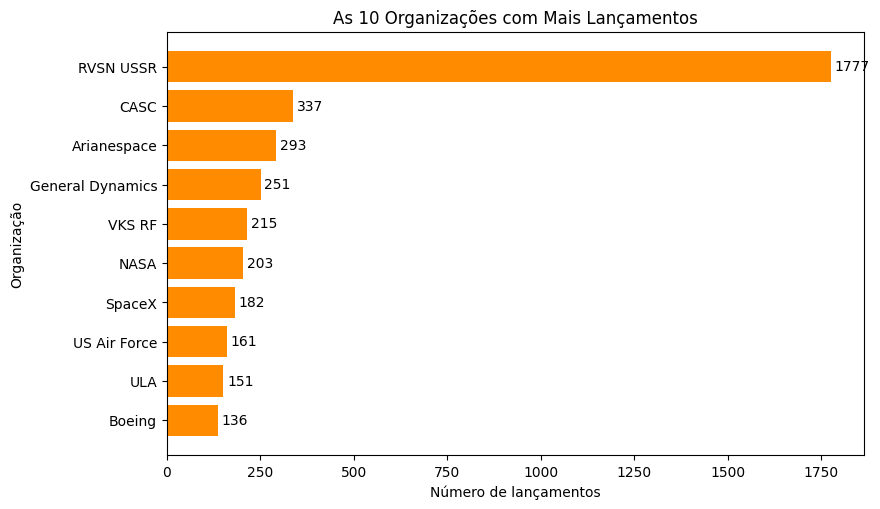

In [23]:
# Pega as 10 organizações com mais lançamentos
top10 = df["Company"].value_counts().head(10)

top10 = top10.sort_values()

plt.figure(figsize=(9, 5.5))
plt.barh(top10.index, top10.values, color="darkorange")

for i in range(len(top10)):
    plt.text(top10.values[i] + 10, i, str(top10.values[i]), va="center")

plt.title("As 10 Organizações com Mais Lançamentos")
plt.xlabel("Número de lançamentos")
plt.ylabel("Organização")
plt.show()

A agência soviética **RVSN USSR** domina o histórico (1.777 lançamentos), reflexo do altíssimo ritmo soviético; nomes recentes como **SpaceX** já figuram entre os dez maiores acumulados.

### Gráfico 4 — Resultado e taxa de sucesso por década (variável `MissionStatus`)

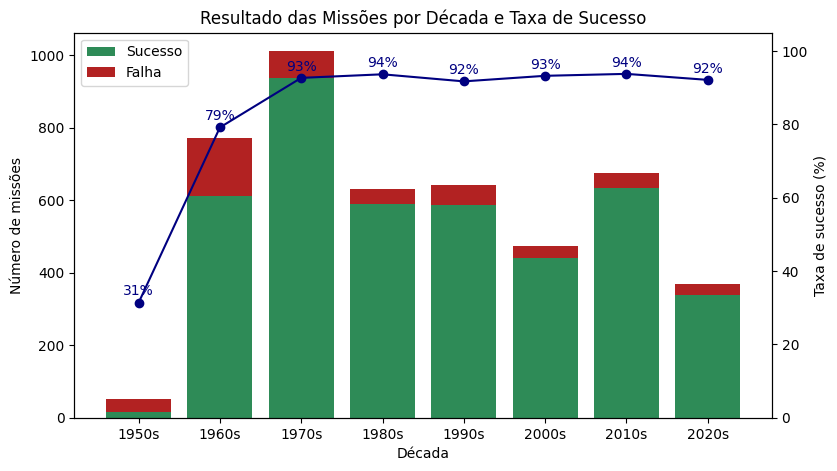

In [24]:
# Conta sucessos e falhas em cada década (separando com um filtro)
sucessos = df[df["MissionStatus"] == 1]["DecadeLbl"].value_counts().sort_index()
falhas   = df[df["MissionStatus"] == 0]["DecadeLbl"].value_counts().sort_index()

taxa_sucesso = sucessos / (sucessos + falhas) * 100

decadas = sucessos.index

fig, eixo1 = plt.subplots(figsize=(9, 5))

# Barras empilhadas: sucessos embaixo, falhas em cima
eixo1.bar(decadas, sucessos.values, color="seagreen", label="Sucesso")
eixo1.bar(decadas, falhas.values, bottom=sucessos.values, color="firebrick", label="Falha")
eixo1.set_xlabel("Década")
eixo1.set_ylabel("Número de missões")
eixo1.legend(loc="upper left")

eixo2 = eixo1.twinx()
eixo2.plot(decadas, taxa_sucesso.values, color="navy", marker="o")
eixo2.set_ylabel("Taxa de sucesso (%)")
eixo2.set_ylim(0, 105)

for i in range(len(decadas)):
    eixo2.text(i, taxa_sucesso.values[i] + 2, str(round(taxa_sucesso.values[i])) + "%",
               ha="center", color="navy")

plt.title("Resultado das Missões por Década e Taxa de Sucesso")
plt.show()

A curva de confiabilidade conta uma história de **aprendizado tecnológico**: de **31%** nos anos 1950 para ~**79%** nos 1960 e estabilização acima de **92%** a partir dos anos 1970.

## 4. Análises Univariadas (Estatística Descritiva)

Para cada variável quantitativa calculamos **tendência central** (média, mediana, moda), **dispersão** (máximo, mínimo, amplitude, variância, desvio padrão) e **separatrizes** (quartis), acompanhadas de interpretação. Incluímos ainda o **coeficiente de variação (CV)** como medida de dispersão relativa.

In [25]:
# Esta função calcula todas as medidas de uma coluna e devolve uma tabela.
#usada duas vezes uma para o Ano e outra para o Preço.
def resumo(coluna, nome):
    dados = coluna.dropna()

    # Medidas de tendência central
    media = dados.mean()
    mediana = dados.median()
    moda = dados.mode()[0]

    # Medidas de dispersão
    maximo = dados.max()
    minimo = dados.min()
    amplitude = maximo - minimo
    variancia = dados.var()
    desvio = dados.std()
    cv = desvio / media * 100

    q1 = dados.quantile(0.25)
    q2 = dados.quantile(0.50)      # o Quartil 2 é a própria mediana
    q3 = dados.quantile(0.75)
    iiq = q3 - q1

    #tabela
    tabela = pd.DataFrame({
        "Medida": ["Quantidade de dados", "Média", "Mediana", "Moda (valor mais comum)",
                   "Máximo", "Mínimo", "Amplitude (máx - mín)", "Variância", "Desvio padrão",
                   "Quartil 1 (25%)", "Quartil 2 - mediana (50%)", "Quartil 3 (75%)",
                   "Intervalo interquartílico", "Coeficiente de variação (%)"],
        nome: [len(dados), round(media, 2), round(mediana, 2), round(moda, 2),
               round(maximo, 2), round(minimo, 2), round(amplitude, 2),
               round(variancia, 2), round(desvio, 2),
               round(q1, 2), round(q2, 2), round(q3, 2), round(iiq, 2), round(cv, 2)]
    })
    tabela = tabela.set_index("Medida")
    return tabela

# Análise da variável discreta: Ano de lançamento
print("Tabela 4.1 - Medidas do ano de lançamento")
resumo(df["Year"], "Ano de lançamento")

Tabela 4.1 - Medidas do ano de lançamento


,Ano de lançamento
Medida,
Quantidade de dados,4626.00
Média,1989.61
Mediana,1987.00
Moda (valor mais comum),2021.00
Máximo,2022.00
Mínimo,1957.00
Amplitude (máx - mín),65.00
Variância,375.33
Desvio padrão,19.37


**O que esta tabela mostra (ano).** Aqui resumimos em poucos números *quando* aconteceram os lançamentos.

- A **média** (cerca de **1989**) e a **mediana** (**1987**) são bem parecidas. Quando esses dois números ficam próximos, é sinal de que os dados estão **equilibrados no tempo**, sem um período "puxando" tudo para um lado.
- Os **quartis** dividem a linha do tempo em quatro partes iguais. Eles indicam que **metade dos lançamentos aconteceu entre 1973 e 2007** — esse foi o período de maior atividade.
- A **moda** é o ano que mais se repete: **2021**, mostrando que os últimos anos têm muitos lançamentos.
- O **coeficiente de variação** é de apenas ~1%, ou seja, os anos são **muito parecidos entre si** (o que é esperado, já que ano é uma data de calendário).

In [26]:
# Análise da variável contínua: Preço por lançamento
print("Tabela 4.2 - Medidas do preço por lançamento (US$ milhões)")
resumo(df["Price"], "Preço por lançamento")

Tabela 4.2 - Medidas do preço por lançamento (US$ milhões)


,Preço por lançamento
Medida,
Quantidade de dados,1264.00
Média,128.41
Mediana,63.00
Moda (valor mais comum),450.00
Máximo,5000.00
Mínimo,2.00
Amplitude (máx - mín),4998.00
Variância,65970.97
Desvio padrão,256.85


**O que esta tabela mostra (preço).** Aqui os números contam uma história interessante:

- A **média** é de cerca de **US$ 128 milhões**, mas a **mediana** é só **US$ 63 milhões** — ou seja, a média é o **dobro** da mediana. Isso acontece porque alguns poucos foguetes caríssimos (o **máximo** chega a **US$ 5.000 milhões**) "puxam" a média para cima. A mediana, que é o valor do meio, não sofre com isso e descreve melhor o preço **típico**.
- Os **quartis** mostram que metade dos lançamentos custou entre **US$ 30 e US$ 116 milhões** — a faixa do mercado "comum".
- O **coeficiente de variação** é altíssimo (cerca de **200%**), e o **desvio padrão** (US$ 257 mi) é até maior que a média. Tudo isso confirma que os preços são **muito desiguais**: existem desde foguetes pequenos e baratos até veículos gigantes e caríssimos.

**Conclusão prática:** quando os valores são tão desiguais, a **mediana** representa melhor o "preço normal" do que a média.

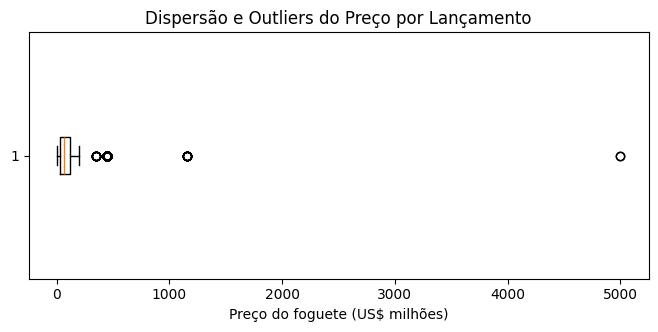

In [27]:
# O boxplot mostra de forma visual a mediana, os quartis e os outliers (pontos isolados)
plt.figure(figsize=(8, 3.2))
plt.boxplot(preco, vert=False)
plt.title("Dispersão e Outliers do Preço por Lançamento")
plt.xlabel("Preço do foguete (US$ milhões)")
plt.show()